TODO:
###### Bruk forskjellige hastigheter og lag plott av målt hastighet versus teoretisk hastighet
###### Undersøk om oppløsningen i dopplerspekteret samsvarer med teoretisk verdi for doppleroppløsning. Tips: Forsøk å estimere 3-dB bredden på det signalet som dere mener representerer dopplerskiftet.
###### Drøft feilkilder og hvilke faktorer som påvirker målenøyaktigheten.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from raspi_import import raspi_import

Bode-plots of the Filter

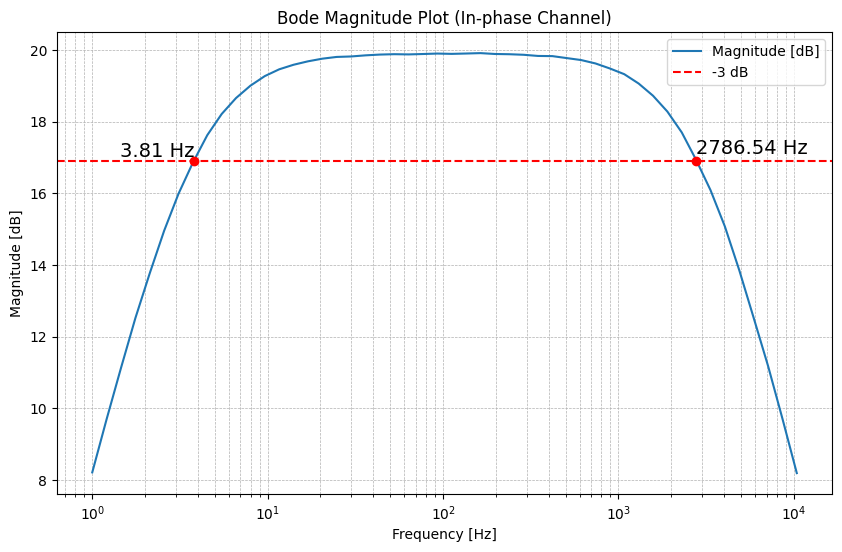

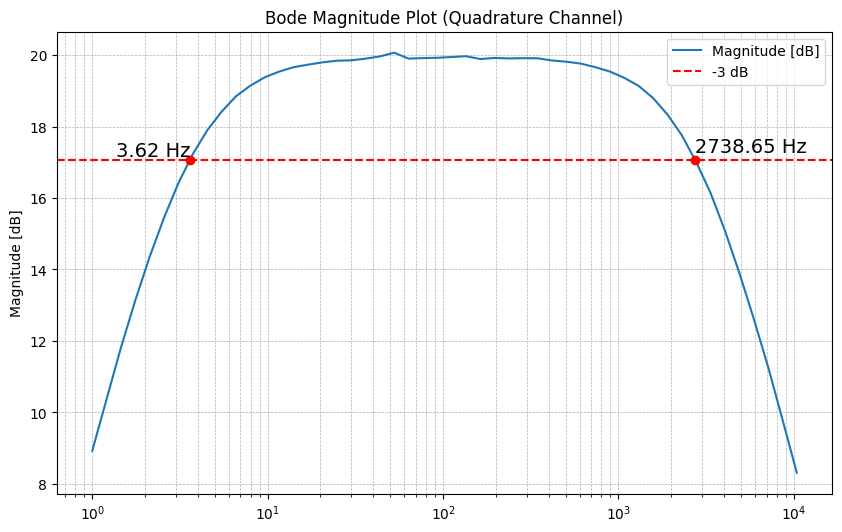

In [3]:
file_path1 = "Målinger/BP_filter_IF_I_Tidy.csv"  
file_path2 = "Målinger/BP_filter_IF_Q_Tidy.csv"  

data1 = pd.read_csv(file_path1)
data2 = pd.read_csv(file_path2)

# WE ARE ASSUMING CSV-files are 'Frequency (Hz)', 'Channel 2 Magnitude (dB)', og 'Channel 2 Phase (deg)'
frequency1 = data1['Frequency (Hz)']
magnitude1 = data1['Channel 2 Magnitude (dB)']
phase1 = data1['Channel 2 Phase (deg)']

max_magnitude1 = np.max(magnitude1)
break1 = max_magnitude1 - 3

frequency2 = data2['Frequency (Hz)']
magnitude2 = data2['Channel 2 Magnitude (dB)']
phase2 = data2['Channel 2 Phase (deg)']

max_magnitude2 = np.max(magnitude2)
break2 = max_magnitude2 - 3

def find_crossing(frequency, magnitude, threshold):
    crossing_indexes = np.where(np.diff(np.sign(magnitude - threshold)))[0]
    crossings = []
    for i in crossing_indexes:
        #Linear interpolation
        x_cross = frequency[i] + (frequency[i+1] - frequency[i]) * (threshold - magnitude[i]) / (magnitude[i+1] - magnitude[i])
        crossings.append(x_cross)
    return crossings

crossings1 = find_crossing(frequency1, magnitude1, break1)
crossings2 = find_crossing(frequency2, magnitude2, break2)

plt.figure(figsize=(10, 6))
plt.semilogx(frequency1, magnitude1, label="Magnitude [dB]")
plt.axhline(break1, color='red', linestyle='--', label='-3 dB')
plt.plot(crossings1[0], break1, 'ro')  
plt.text(crossings1[0], break1+0.1, f"{crossings1[0]:.2f} Hz", color='black', fontsize=14, ha='right')
plt.plot(crossings1[1], break1, 'ro')  
plt.text(crossings1[1], break1+0.2, f"{crossings1[1]:.2f} Hz", color='black', fontsize=14, ha='left')
plt.title("Bode Magnitude Plot (In-phase Channel)")
plt.ylabel("Magnitude [dB]")
plt.xlabel("Frequency [Hz]")
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.semilogx(frequency2, magnitude2, label="Magnitude [dB]")
plt.axhline(break2, color='red', linestyle='--', label='-3 dB')
plt.plot(crossings2[0], break2, 'ro')  
plt.text(crossings2[0], break2+0.1, f"{crossings2[0]:.2f} Hz", color='black', fontsize=14, ha='right')
plt.plot(crossings2[1], break2, 'ro')  
plt.text(crossings2[1], break2+0.2, f"{crossings2[1]:.2f} Hz", color='black', fontsize=14, ha='left')
plt.title("Bode Magnitude Plot (Quadrature Channel)")
plt.ylabel("Magnitude [dB]")
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

Time-domain Plot

TIME DOMAIN OF RAW DATA


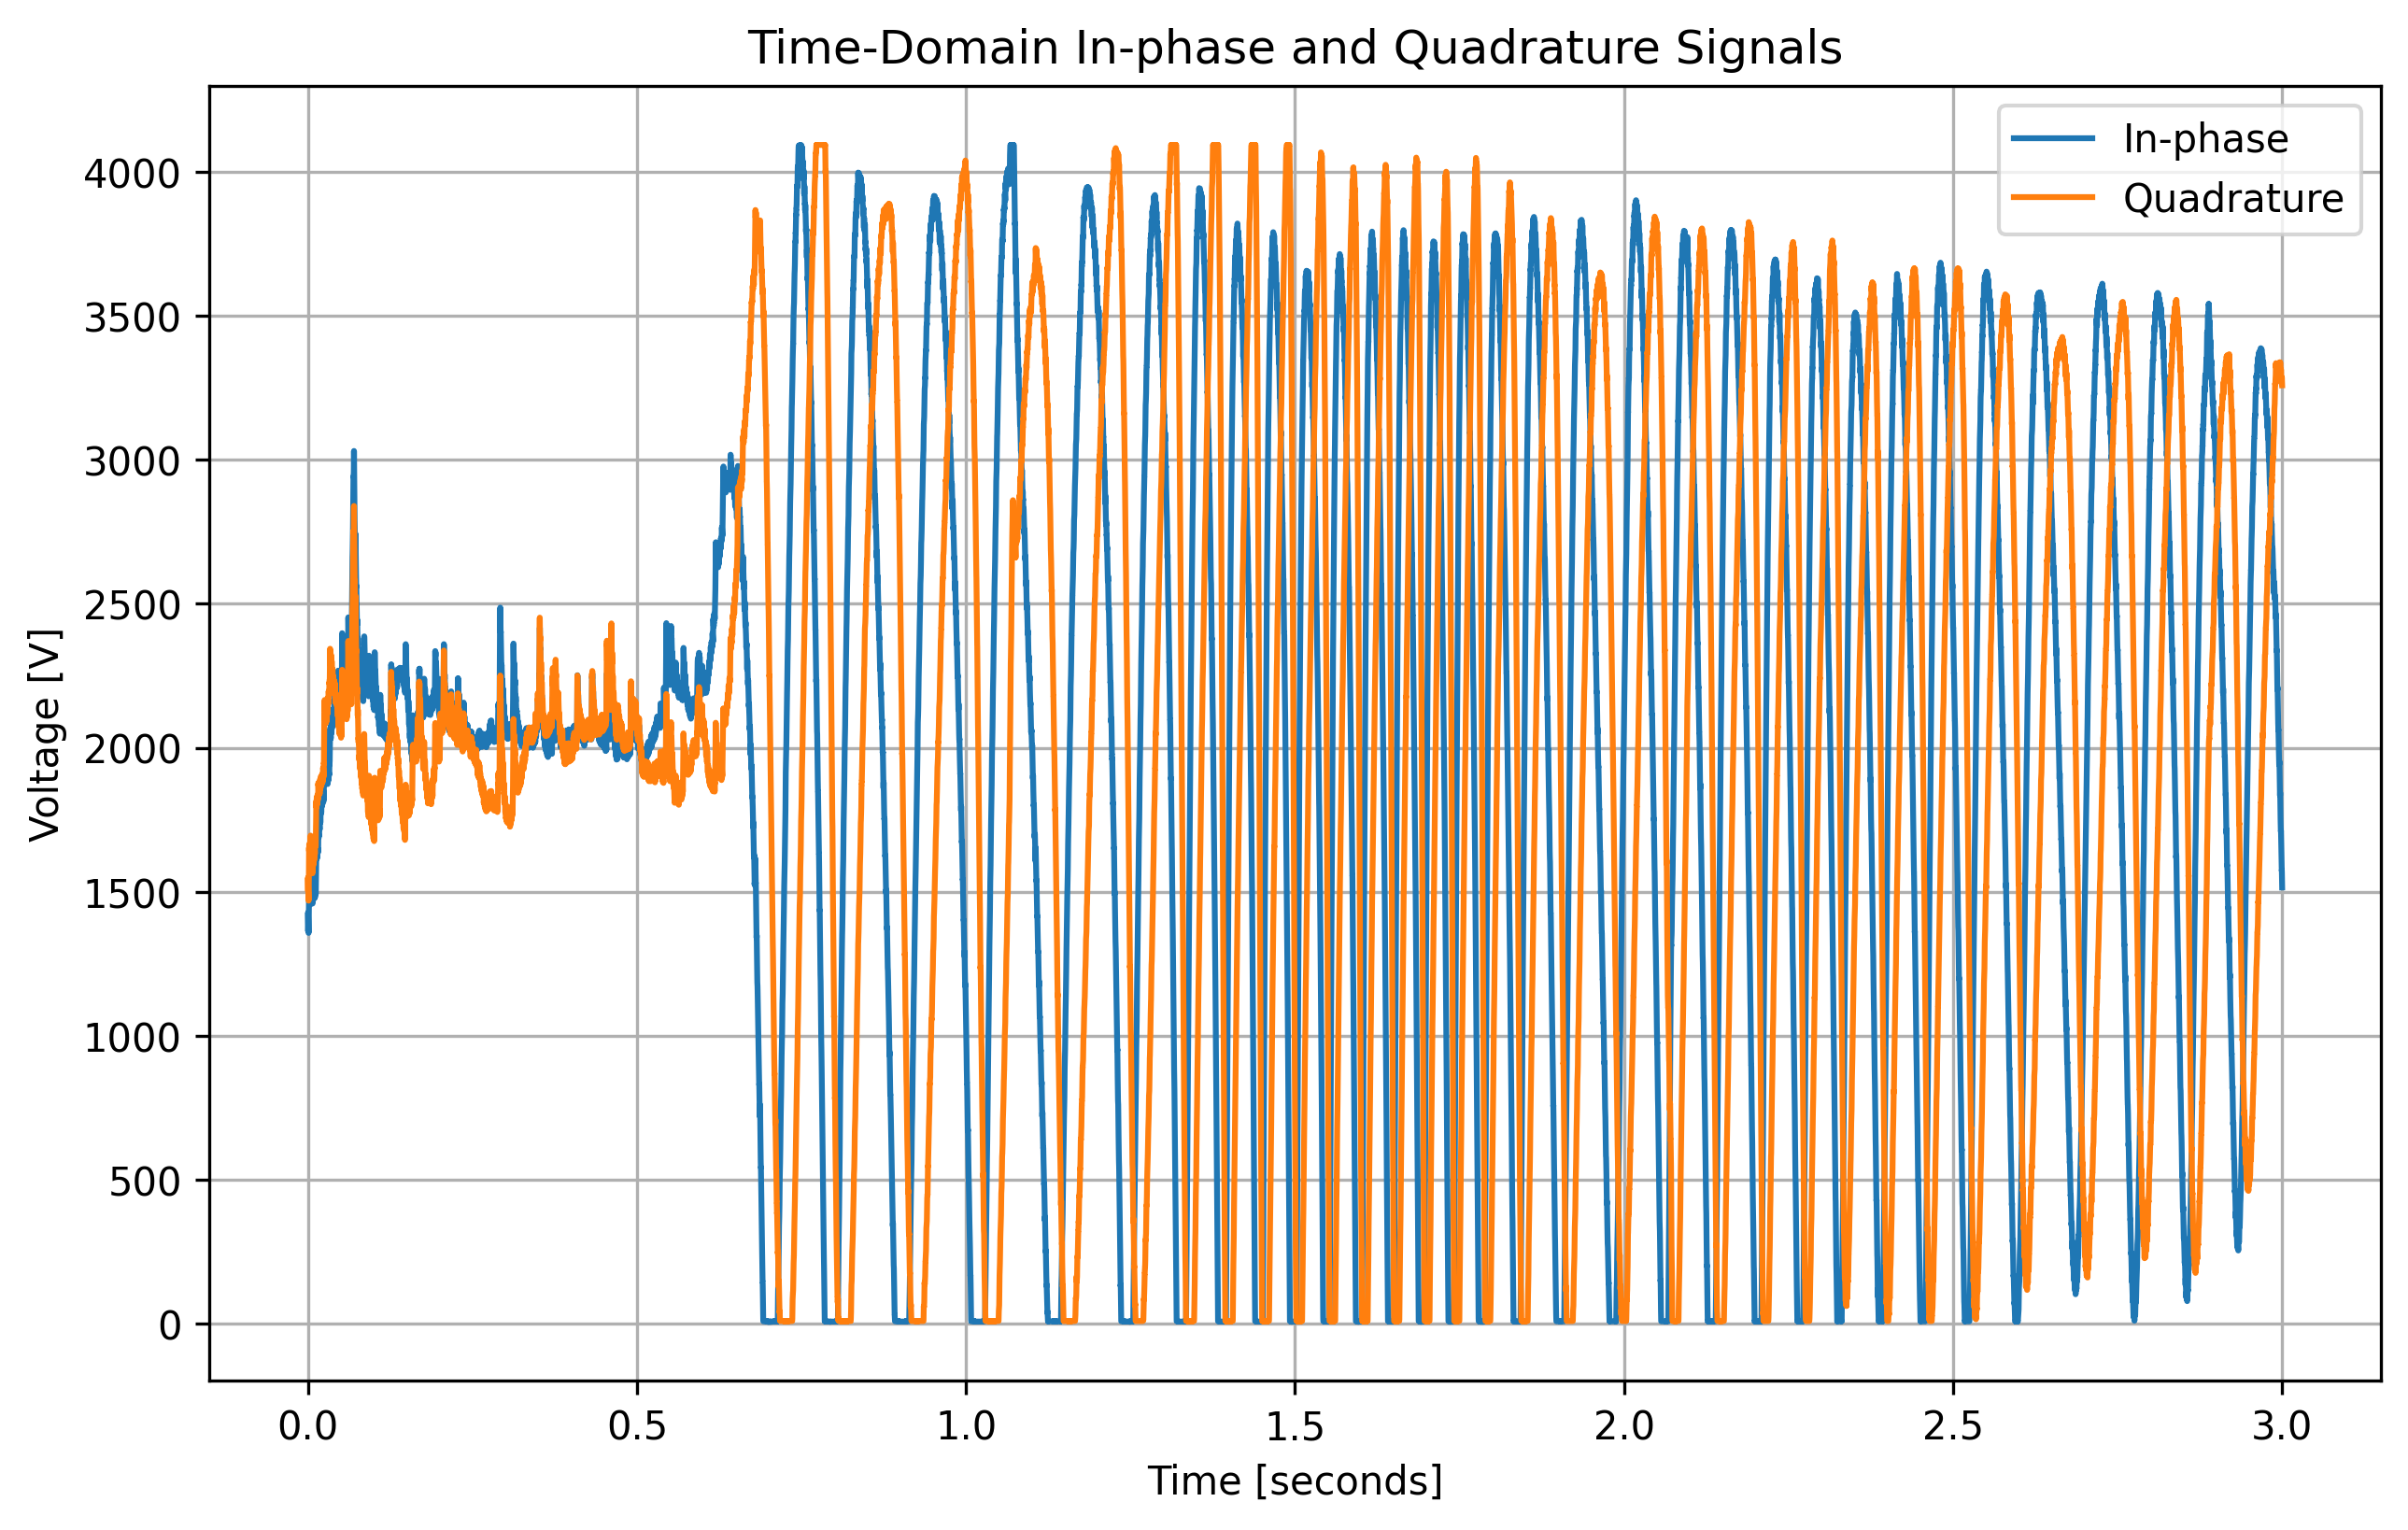

In [4]:
sample_period, data = raspi_import("Målinger/Radar_vekk1.bin", 3) #!!!

fs = 1 / sample_period
N = len(data)

#ASSUME first is In-phase and second Quadrature
In_phase = data[:, 0]
Quadrature = data[:, 1]

time = np.arange(len(In_phase)) * sample_period

print("TIME DOMAIN OF RAW DATA")
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(time, In_phase, label="In-phase")
plt.plot(time, Quadrature, label="Quadrature")
plt.title("Time-Domain In-phase and Quadrature Signals")
plt.xlabel("Time [seconds]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.grid()
plt.show()

AMPLITUDE MATCHING RAW DATA


RMS of the In-phase Signal: 1209.7666536795502
RMS of the Quadrature Signal: 1215.4486974676656
New RMS of Quadrature Signal: 1209.76665367955


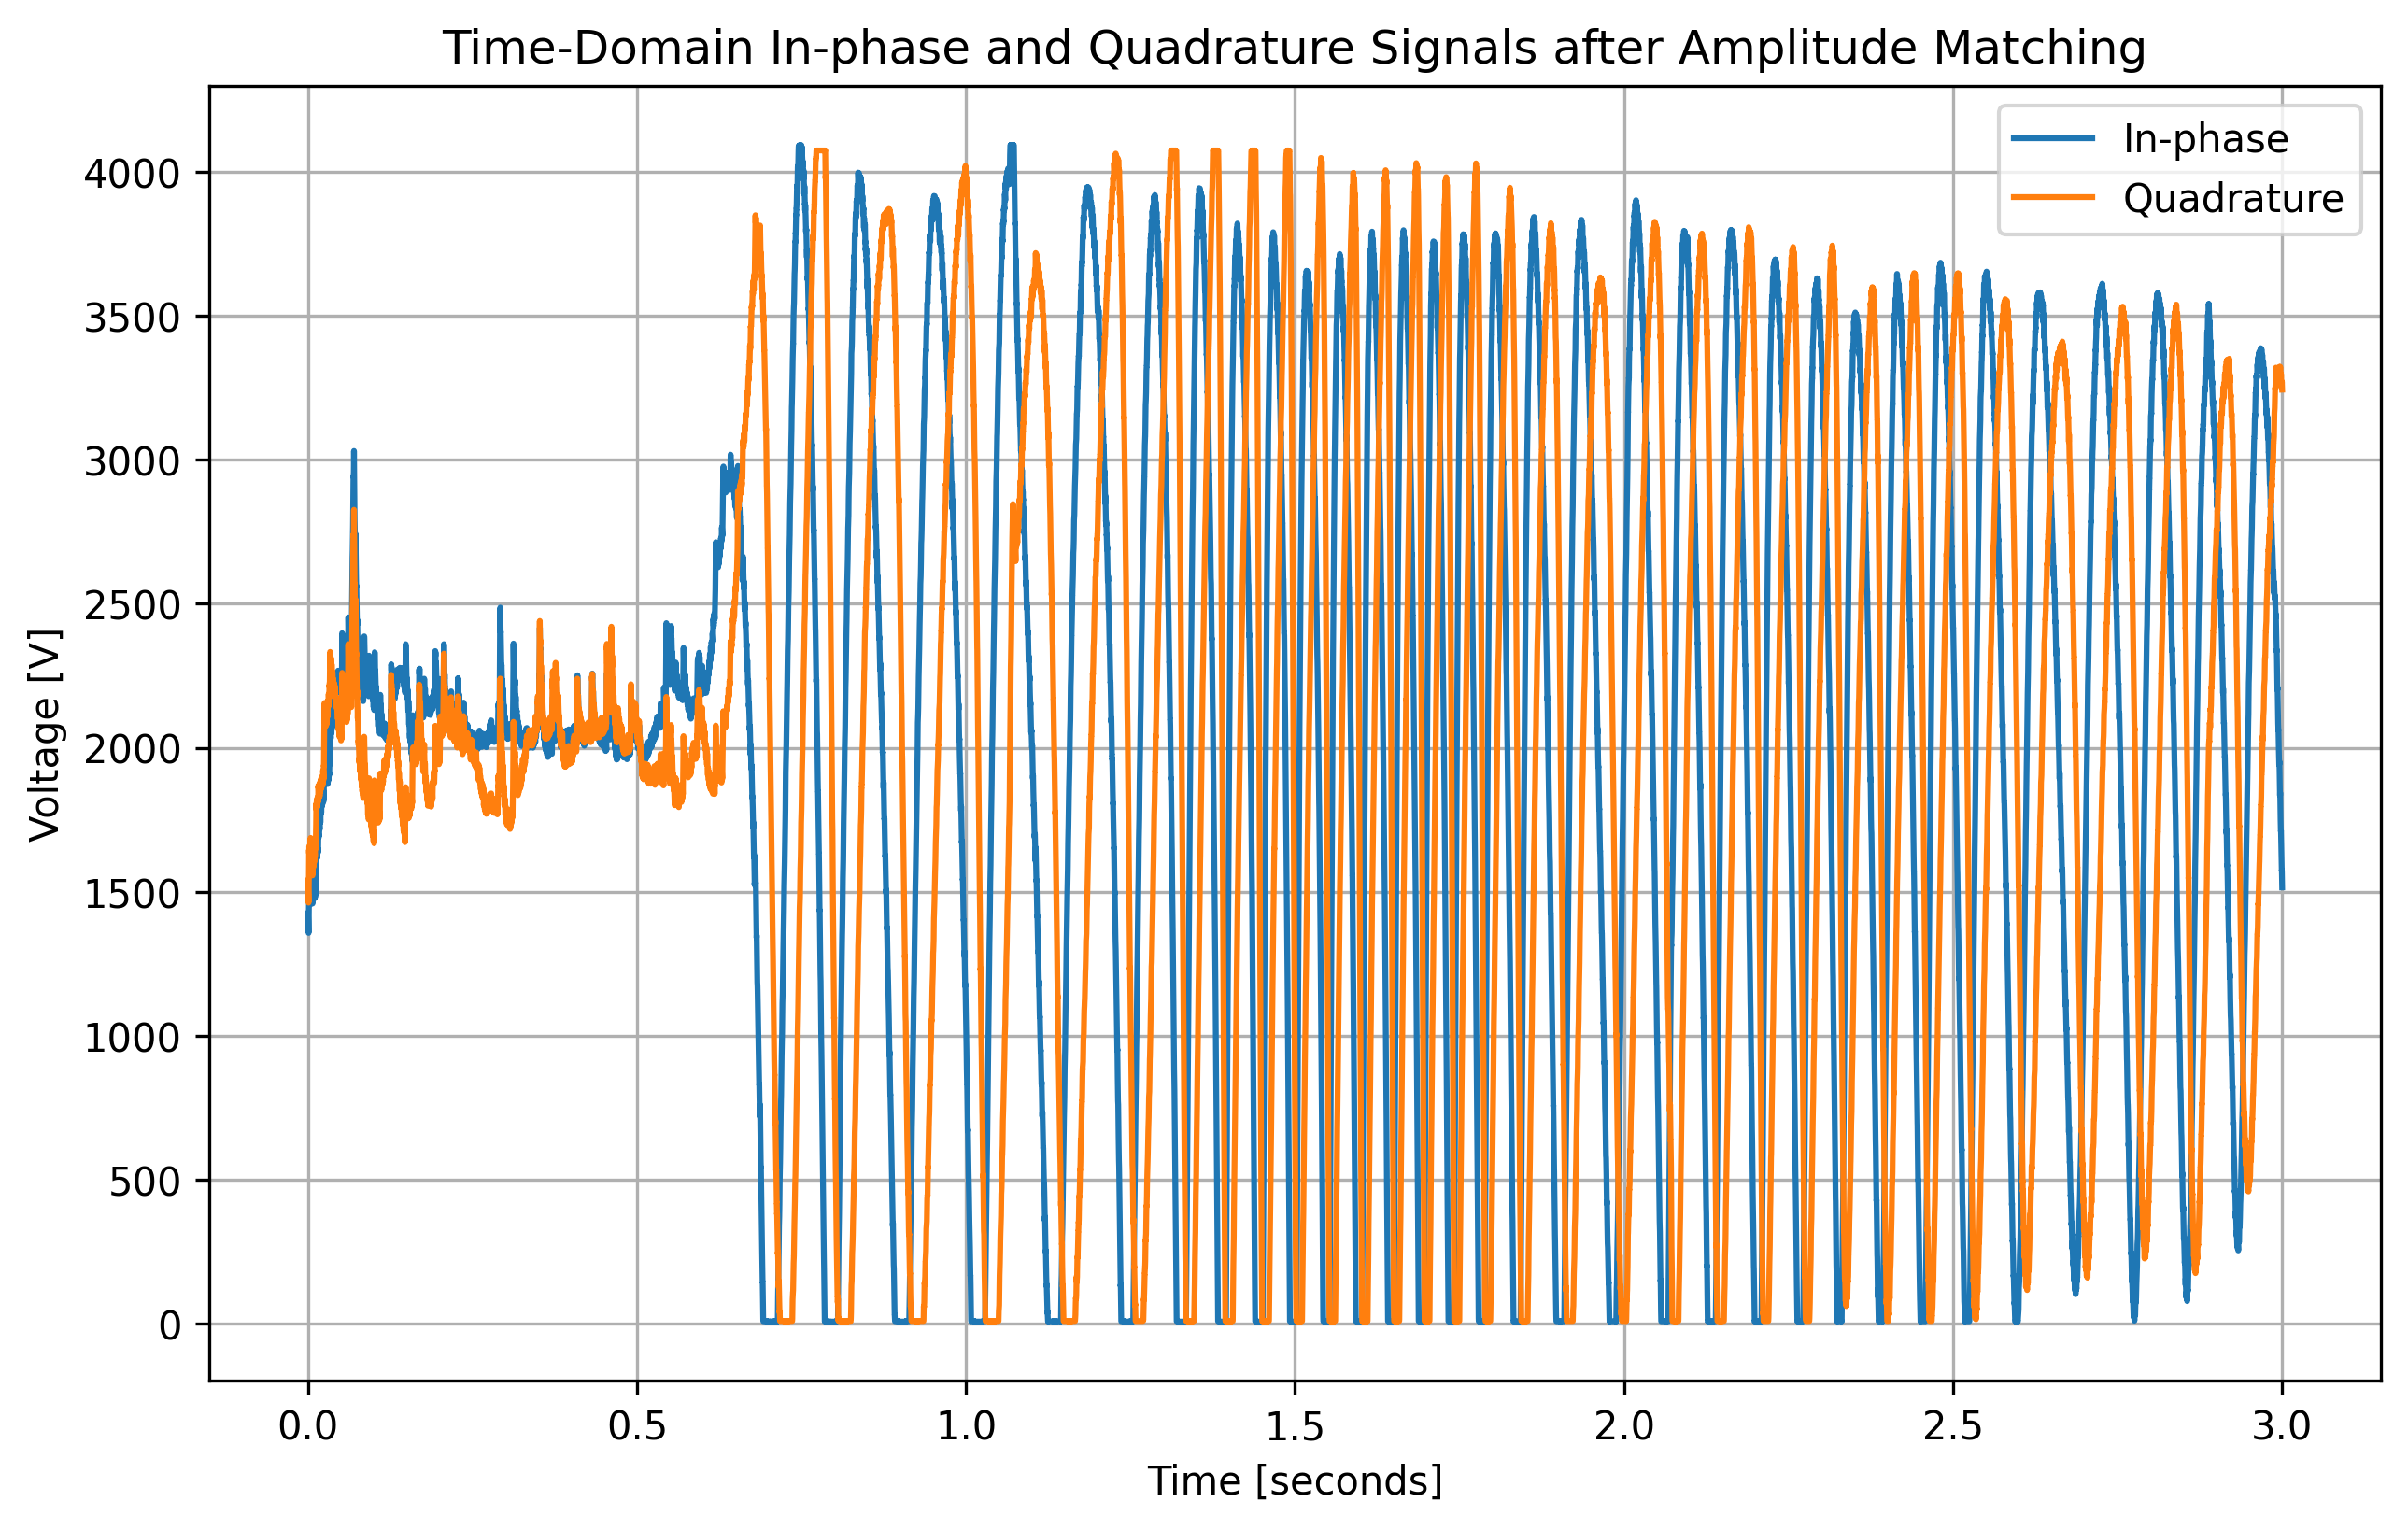

In [5]:
print("AMPLITUDE MATCHING RAW DATA\n\n")

rms_I = np.std(In_phase)
rms_Q = np.std(Quadrature)

print("RMS of the In-phase Signal:", rms_I)
print("RMS of the Quadrature Signal:", rms_Q)

scale = rms_I / rms_Q
Quadrature = Quadrature * scale
rms_Q = np.std(Quadrature)

print("New RMS of Quadrature Signal:", rms_Q)

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(time, In_phase, label="In-phase")
plt.plot(time, Quadrature, label="Quadrature")
plt.title("Time-Domain In-phase and Quadrature Signals after Amplitude Matching")
plt.xlabel("Time [seconds]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.grid()
plt.show()

FFTs and Velocity

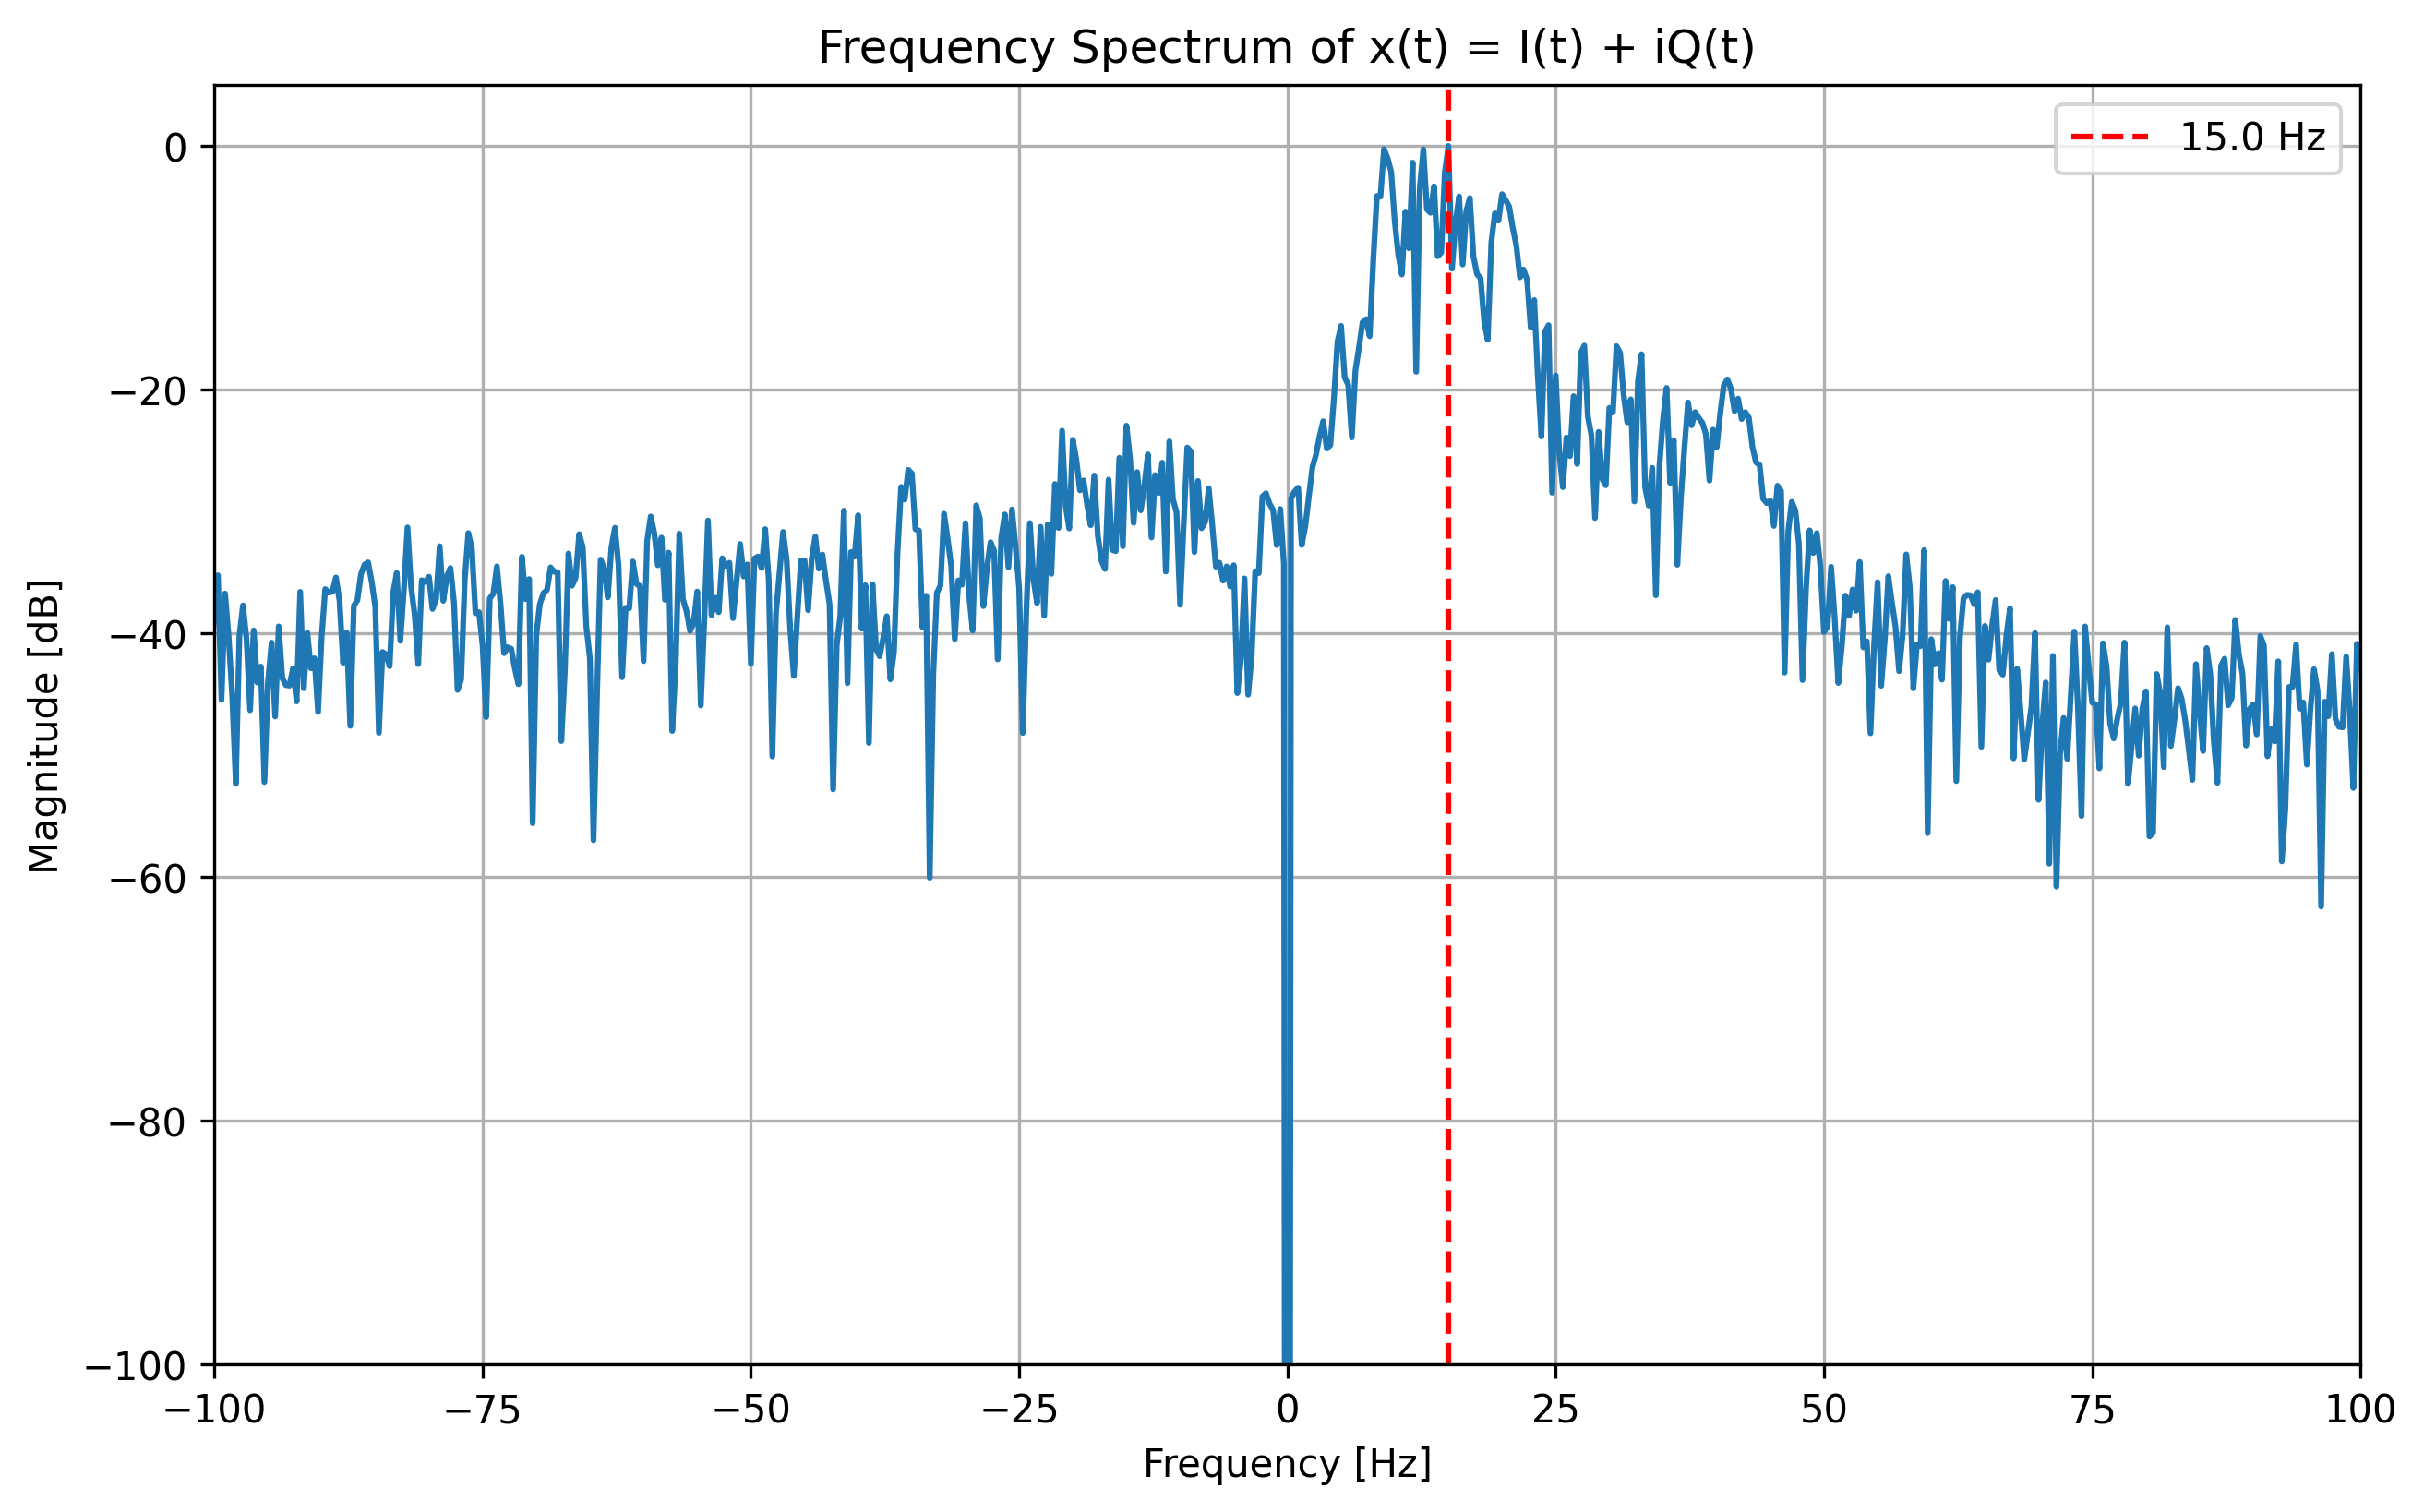

In [6]:
#Remove DC offset
In_phase = In_phase - np.mean(In_phase)
Quadrature = Quadrature - np.mean(Quadrature)

s = In_phase + 1j * Quadrature

S = np.fft.fft(s)
S = np.fft.fftshift(S)
S_db = 20 * np.log10(np.abs(S)) #Maybe + 1e-12

freq = np.fft.fftfreq(N, sample_period)
freq = np.fft.fftshift(freq)

#Doppler peak
doppler_index = np.argmax(np.abs(S))
freq_doppler = freq[doppler_index]

plt.figure(figsize=(10,6),dpi=300)
plt.plot(freq, S_db-np.max(S_db))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Frequency Spectrum of x(t) = I(t) + iQ(t)")
plt.axvline(freq_doppler, color="red", linestyle="--", label=f"{freq_doppler} Hz") #Better label and showing of value
plt.legend()
plt.xlim(-100, 100)
plt.ylim(-100, 5)
plt.grid()
plt.show()

In [7]:
c = 3e8
f_radar = 24e9

velocity = (freq_doppler*c)/(2*f_radar)

print("Doppler frequency:", freq_doppler, "Hz")
print("Velocity:", velocity, "m/s")

Doppler frequency: 15.0 Hz
Velocity: 0.09375 m/s


Filtered Signal

Time-Domain

RMS of the In-phase Signal: 862.5964451953595
RMS of the Quadrature Signal: 875.6511916718617
New RMS of Quadrature Signal: 862.5964451953595


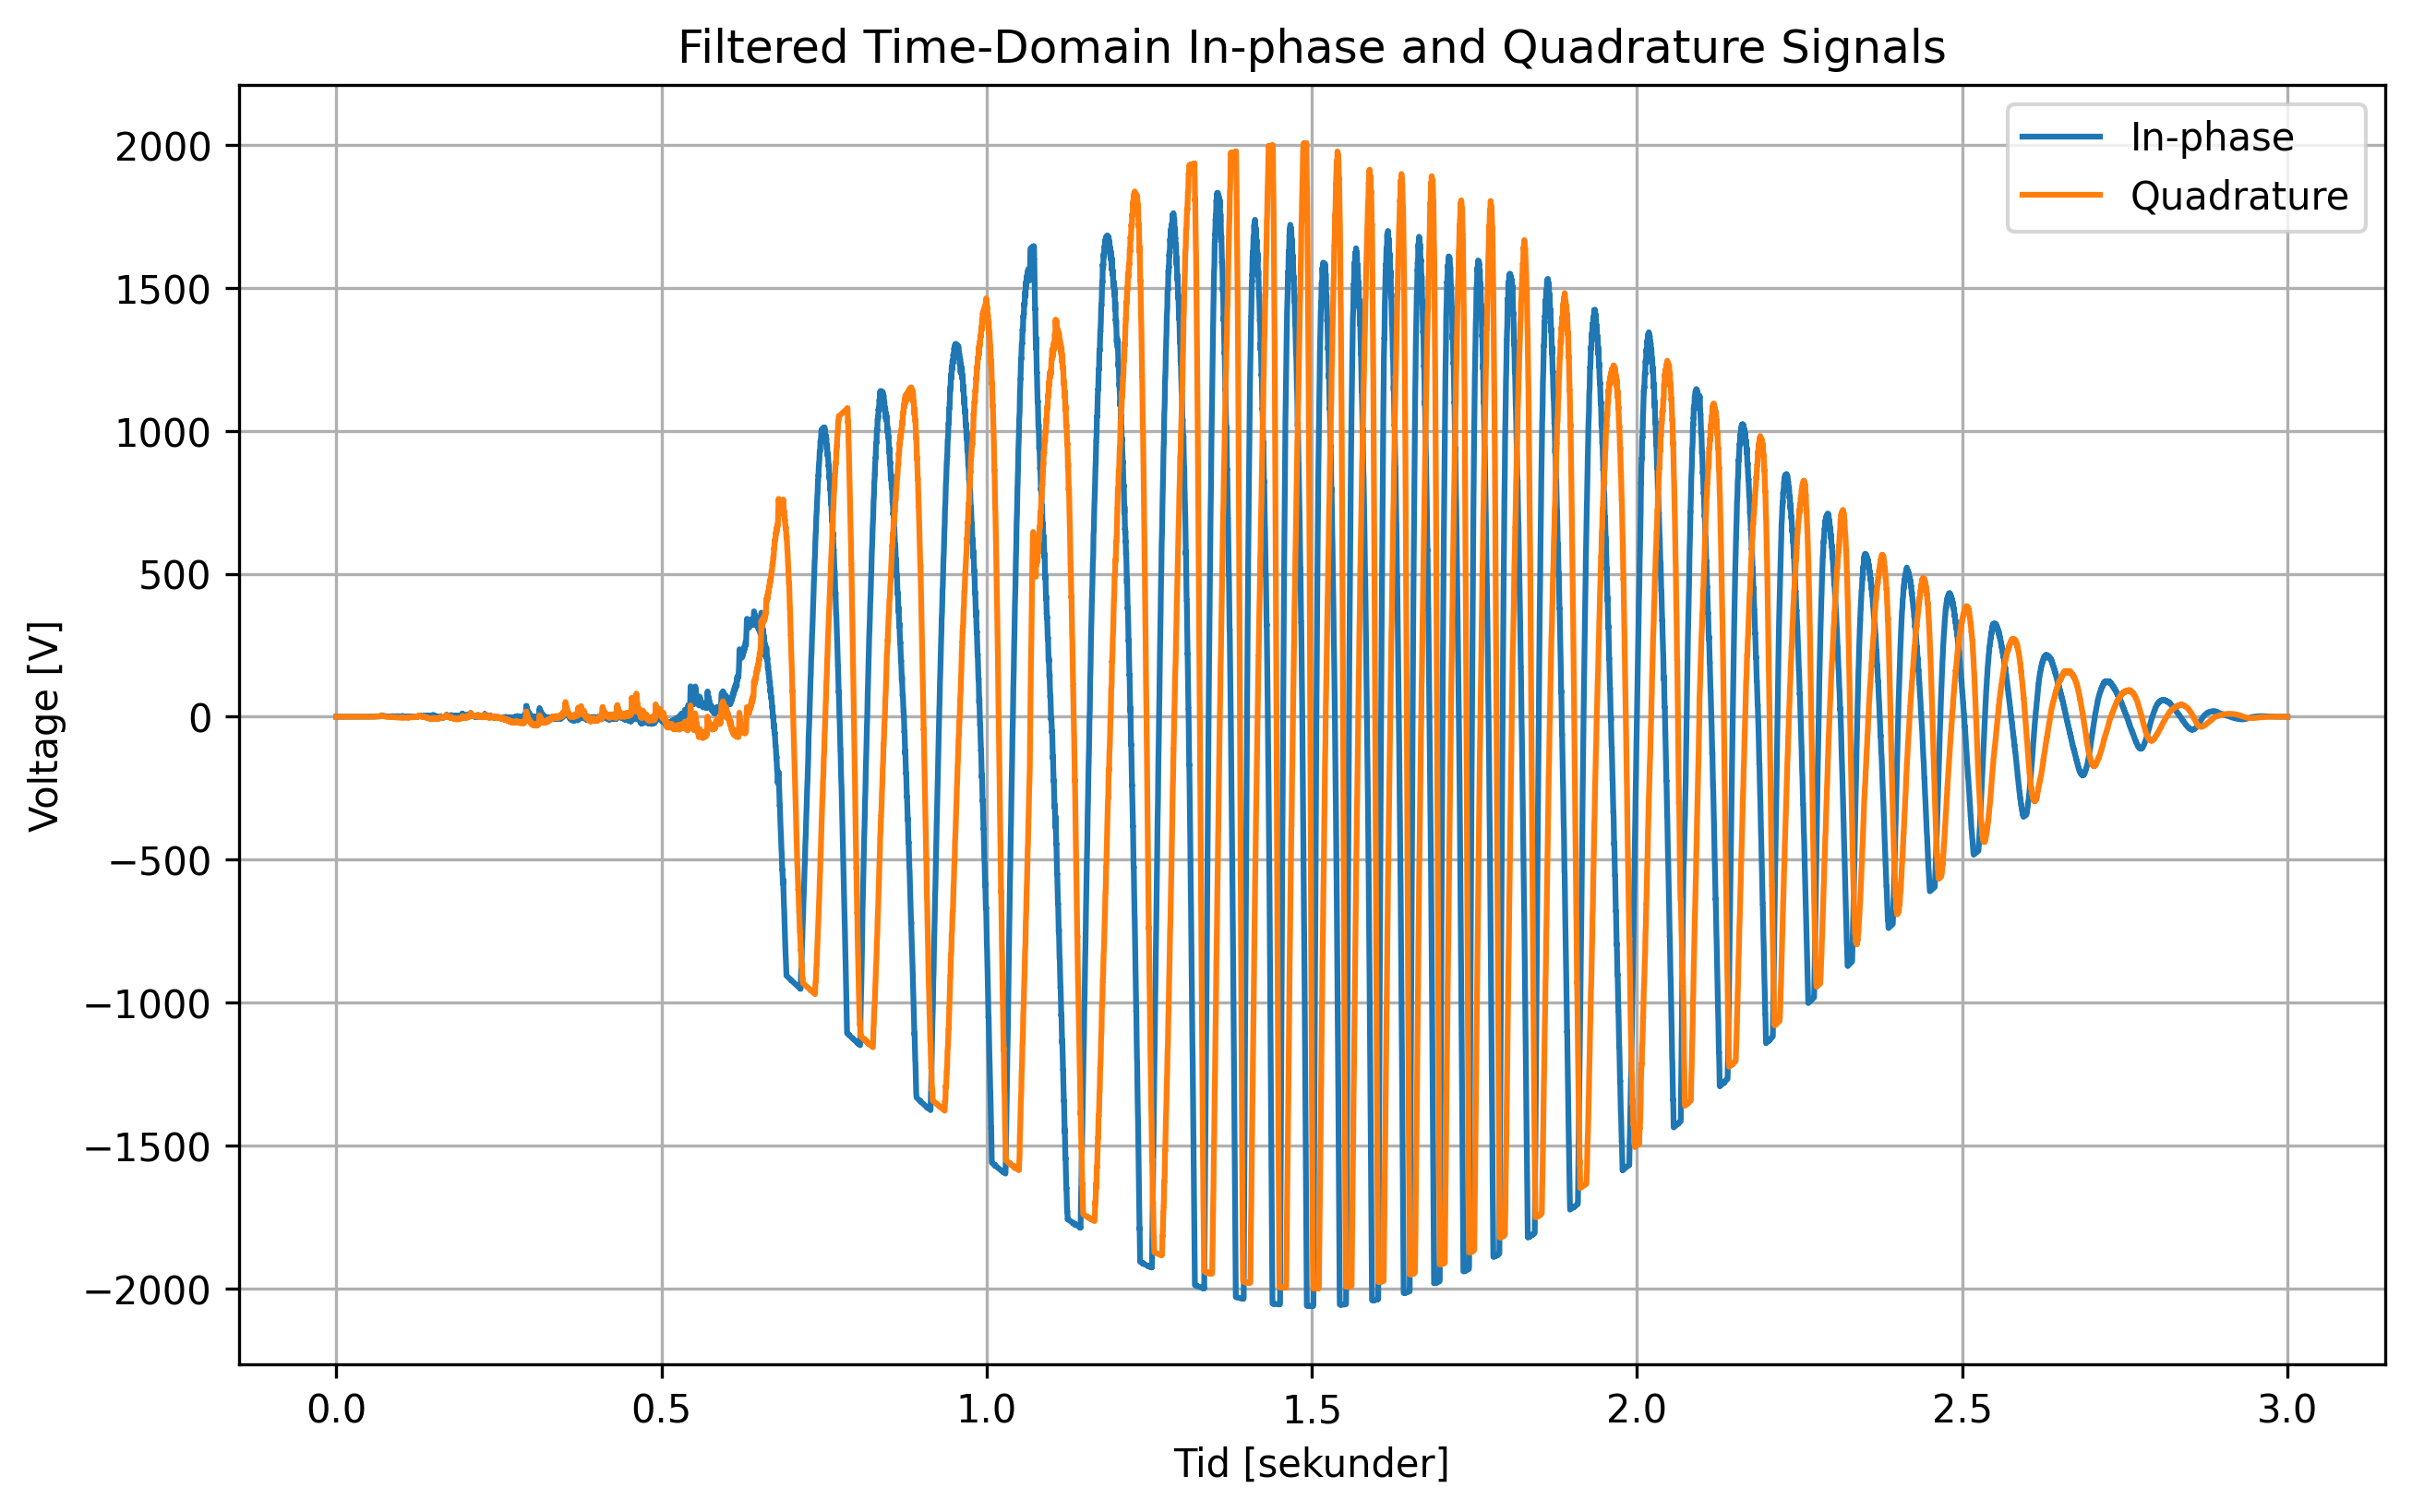

In [8]:
window = np.hanning(N) #Cut the noise from the edge
filtered_In_phase = In_phase * window
filtered_Quadrature = Quadrature * window

rms_I = np.std(filtered_In_phase)
rms_Q = np.std(filtered_Quadrature)

print("RMS of the In-phase Signal:", rms_I)
print("RMS of the Quadrature Signal:", rms_Q)

scale = rms_I / rms_Q
filtered_Quadrature = filtered_Quadrature * scale
rms_Q = np.std(filtered_Quadrature)

print("New RMS of Quadrature Signal:", rms_Q)

time = np.arange(len(filtered_In_phase)) * sample_period

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(time, filtered_In_phase, label="In-phase")
plt.plot(time, filtered_Quadrature, label="Quadrature")
plt.title("Filtered Time-Domain In-phase and Quadrature Signals")
plt.xlabel("Tid [sekunder]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.grid()
plt.show()


FFTs and Velocity

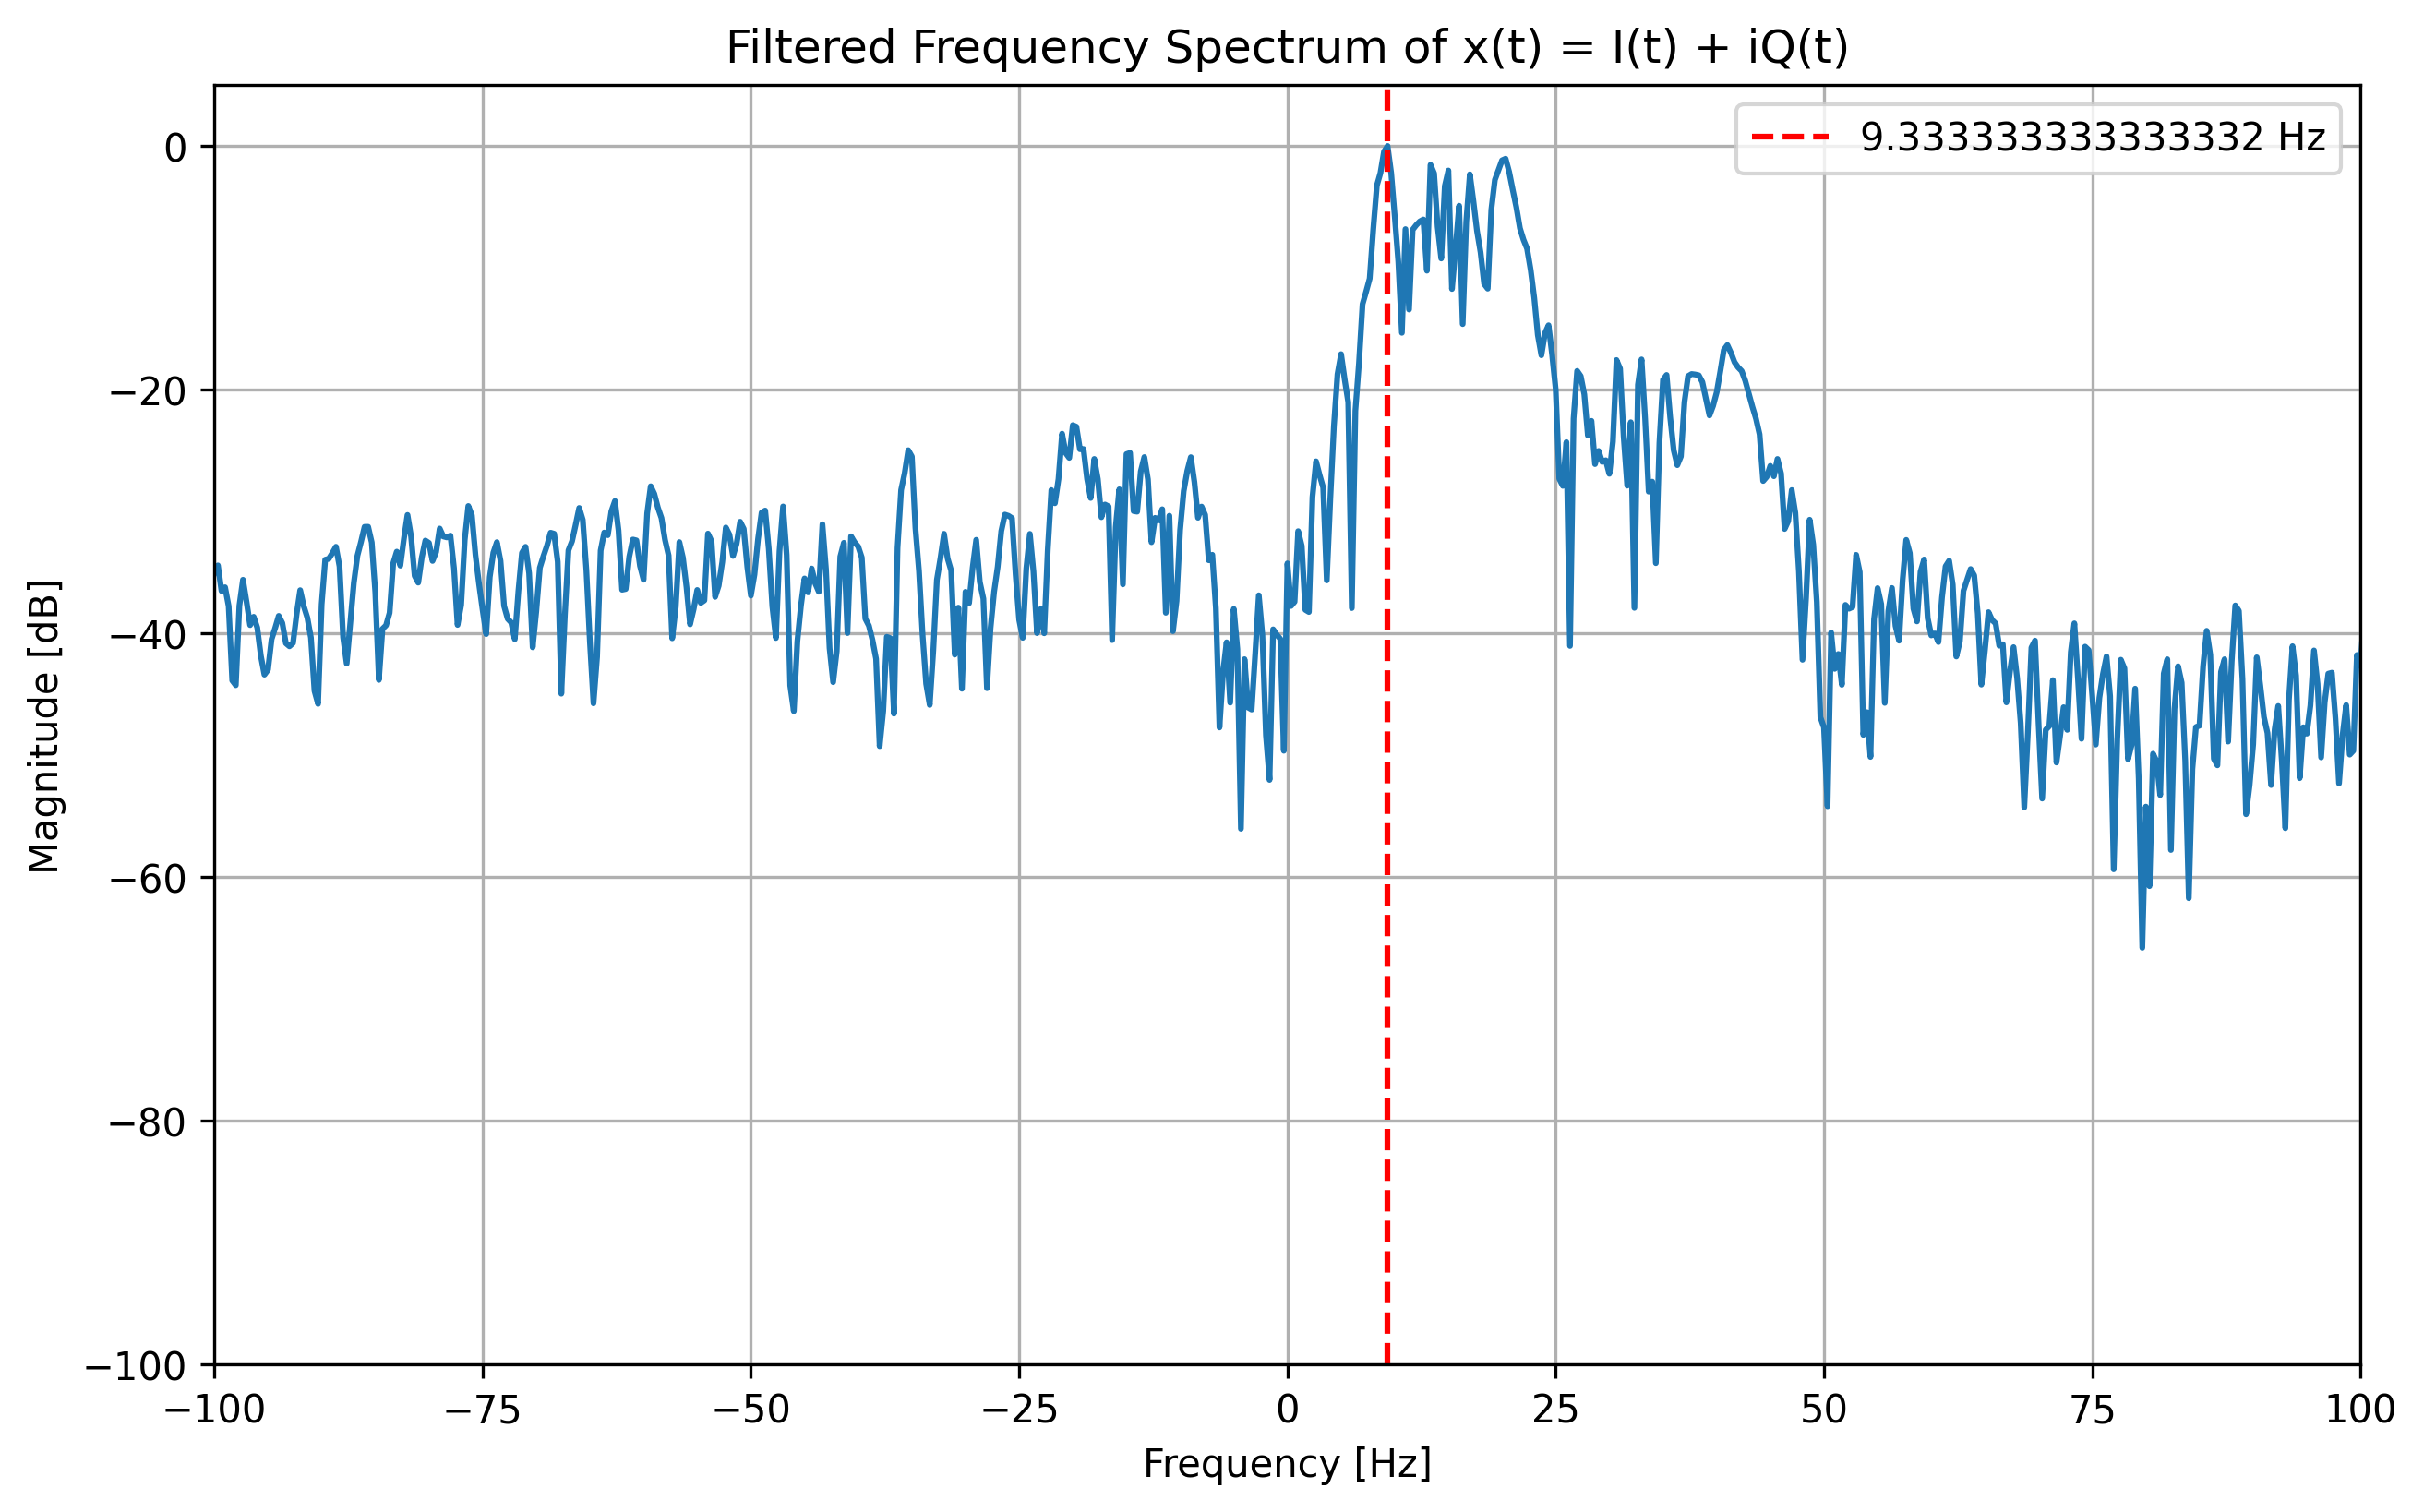

In [12]:
s = filtered_In_phase + 1j*filtered_Quadrature
S = np.fft.fft(s)
S = np.fft.fftshift(S)
S_db = 20 * np.log10(np.abs(S)) #Maybe +1e-12

freq = np.fft.fftfreq(N, sample_period)
freq = np.fft.fftshift(freq)

doppler_index = np.argmax(np.abs(S))
freq_doppler = freq[doppler_index]

plt.figure(figsize=(10,6),dpi=300)
plt.plot(freq, S_db-np.max(S_db))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Filtered Frequency Spectrum of x(t) = I(t) + iQ(t)")
plt.axvline(freq_doppler, color="red", linestyle="--", label=f"{freq_doppler} Hz")
plt.legend()
plt.xlim(-100, 100)
plt.ylim(-100, 5)
plt.grid()
plt.show()

In [10]:
c = 3e8
f_radar = 24e9

velocity = (freq_doppler*c)/(2*f_radar)

print("Doppler frequency:", freq_doppler, "Hz")
print("Velocity:", velocity, "m/s")

Doppler frequency: 9.333333333333332 Hz
Velocity: 0.05833333333333332 m/s


SNR

BEFORE FILTERING


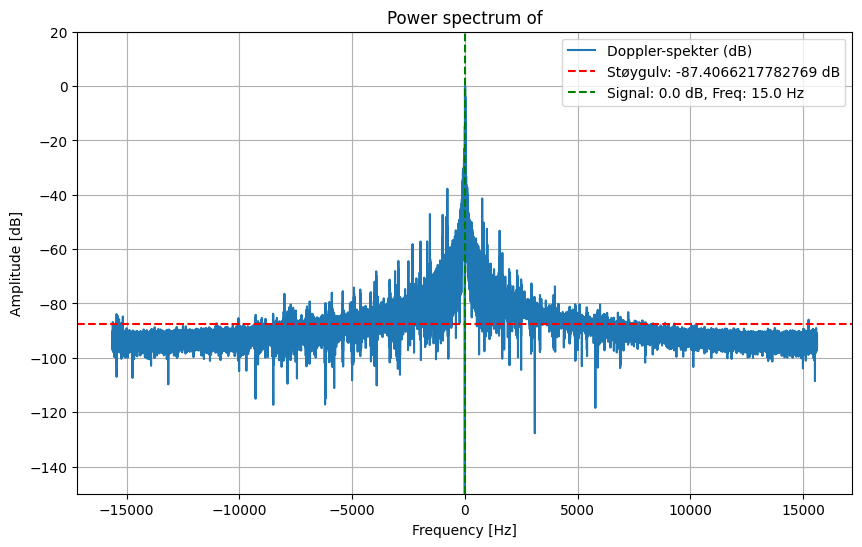

SNR: 87.4066217782769 dB
Støygulv: -87.4066217782769 dB
Signalstyrke: 0.0 dB



 AFTER FILTERING


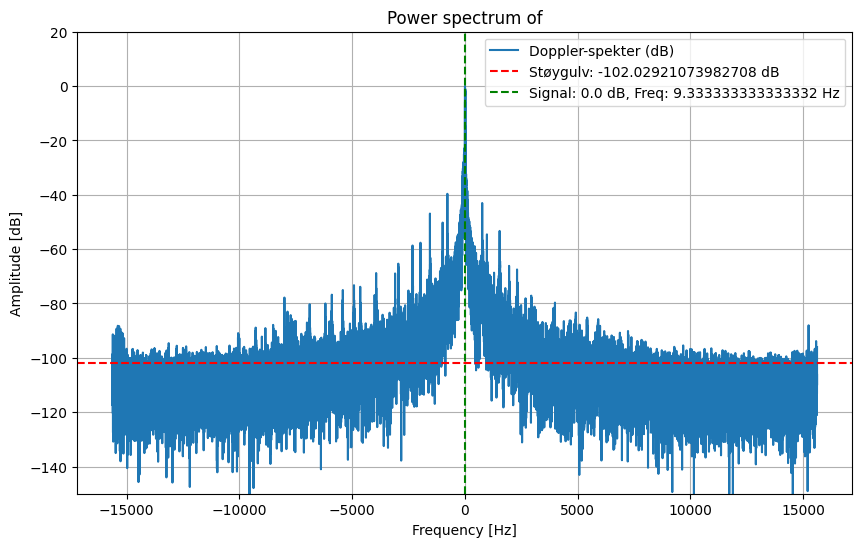

SNR etter filtrering: 102.02921073982708 dB
Støygulv etter filtrering: -102.02921073982708 dB
Signalstyrke etter filtrering: 0.0 dB


In [23]:
In_phase = data[:, 0]
Quadrature = data[:, 1]

In_phase = In_phase - np.mean(In_phase)
Quadrature = Quadrature - np.mean(Quadrature)

s = In_phase + 1j*Quadrature
filtered_s = filtered_In_phase + 1j*filtered_Quadrature

def analyze_doppler_spectrum(s, fs):
    S = np.fft.fft(s)
    S = np.fft.fftshift(S)
    S_power_dB = 10 * np.log10(np.abs(S)**2) #Power = 20log(). Mybe np.abs(S)+1e-11

    freq = np.fft.fftfreq(len(S), d=1/fs)
    freq = np.fft.fftshift(freq)

    #Normalize
    signal_peak = np.max(S_power_dB)
    S_db_normalized = S_power_dB - signal_peak

    signal_peak = np.max(S_db_normalized) 
    index_peak = np.argmax(S_db_normalized)

    mask = np.ones(len(S_db_normalized), dtype=bool)
    mask[index_peak-50:index_peak+50] = False
    noise_floor = np.mean(S_db_normalized[mask])

    snr = signal_peak - noise_floor

    plt.figure(figsize=(10, 6))
    plt.plot(freq, S_db_normalized, label="Doppler-spekter (dB)")
    plt.axhline(noise_floor, color='red', linestyle='--', label=f"Støygulv: {noise_floor} dB")
    plt.axvline(freq[index_peak], color='green', linestyle='--', label=f"Signal: {signal_peak} dB, Freq: {freq[index_peak]} Hz")
    plt.title("Power spectrum of")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude [dB]")
    plt.ylim(-150,20)
    #plt.xlim(-100,100)
    plt.legend()
    plt.grid()
    plt.show()

    return {
        "frequencies": freq,
        "doppler_spectrum_db_normalized": S_db_normalized,
        "noise_floor": noise_floor,
        "signal_peak": signal_peak,
        "snr": snr
    }

print("BEFORE FILTERING")
results = analyze_doppler_spectrum(s, fs)
print(f"SNR: {results['snr']} dB")
print(f"Støygulv: {results['noise_floor']} dB")
print(f"Signalstyrke: {results['signal_peak']} dB\n")


print("\n\n AFTER FILTERING")
results_filtered = analyze_doppler_spectrum(filtered_s, fs)
print(f"SNR etter filtrering: {results_filtered['snr']} dB")
print(f"Støygulv etter filtrering: {results_filtered['noise_floor']} dB")
print(f"Signalstyrke etter filtrering: {results_filtered['signal_peak']} dB")

Varians og standardavik av målt data vs faktisk

In [27]:
#Measured speeds for chosen for chosen Speed, Speed2, Speedb
Speed1_forward = []
Speed2_forward = []
Speed_backward = []

mean_speed_forward = np.mean(Speed1_forward)
variance_forward = np.var(Speed1_forward)
std_deviation_forward = np.sqrt(variance_forward)

mean2_speed_forward = np.mean(Speed2_forward)
variance2_forward = np.var(Speed2_forward)
std2_deviation_forward = np.sqrt(variance2_forward)

mean_speed_backwards = np.mean(Speed_backward)
variance_backwards = np.var(Speed_backward)
std_deviation_bakover = np.sqrt(variance_backwards)

print("Speed X forwards")
print(f"Gjennsnitt: {mean_speed_forward} m/s")
print(f"Varians: {variance_forward} (m/s)^2")
print(f"Standardavvik: {std_deviation_forward} m/s")

print("\n\nSpeed X forwards")
print(f"Gjennsnitt: {mean2_speed_forward} m/s")
print(f"Varians: {variance2_forward} (m/s)^2")
print(f"Standardavvik: {std2_deviation_forward} m/s")

print("\n\nSpeed X backwards")
print(f"Gjennsnitt: {mean_speed_backwards} m/s")
print(f"Varians: {variance_backwards} (m/s)^2")
print(f"Standardavvik: {std_deviation_bakover} m/s")

Speed X forwards
Gjennsnitt: nan m/s
Varians: nan (m/s)^2
Standardavvik: nan m/s


Speed X forwards
Gjennsnitt: nan m/s
Varians: nan (m/s)^2
Standardavvik: nan m/s


Speed X backwards
Gjennsnitt: nan m/s
Varians: nan (m/s)^2
Standardavvik: nan m/s
